# Case 3: Behavioral responses (elasticity of taxable income)

Produces `output/figs/case_3_pareto_schedules.png` and the convergence table for the manuscript.

**Method:**

- **Primary:** the coupled reform-with-behavior program is solved directly as a nonconvex quadratic program via the package's `behavioral_effects=True` constraint (income response $\Delta_i = \delta\,\frac{\tau_i^{sq} - \tau_i^{new}}{1 - \tau_i^{sq}}\,x_i$, taxed at the new marginal rate: exact under bracket stability).
- **Objective:** minimize revenue loss subject to the same income guarantees as the earlier reform examples (no budget bound, no second stage).
- **Validation:** Algorithm 1 (the damped fixed-point LP iteration, the fallback for solvers without quadratic support) is run on the same grid and compared against the direct solve.

Elasticity grid: $\delta \in \{0, 0.05, 0.10, 0.15, 0.20, 0.25\}$. Guarantees: $\geq 5\%$ net-income gain below €70k, $\leq 10\%$ net-income loss above, ascending brackets on support $[0, 25\text{k}, 50\text{k}, 75\text{k}, 100\text{k}, 1\text{M}]$.

In [1]:
## Load libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import shared helpers and TaxSolver components
from case_helpers import (
    tx, DataLoader, BracketInput,
    BudgetConstraint, IncomeConstraint, MarginalPressureConstraint, BracketConstraint,
    BudgetObjective, GurobiBackend,
    get_sq_marginal_rate_case1,
    euro_format,
)

In [2]:
## Load data and status-quo quantities
file_path = os.path.join('data', 'simple_simul_1000.xlsx')
df_taxpayers = pd.read_excel(file_path)

X_ORIG = df_taxpayers['income_before_tax'].to_numpy(float)
Y_SQ = (df_taxpayers['income_before_tax'] - df_taxpayers['outcome_1']).to_numpy(float)  # status-quo tax (solver balance)
NET_SQ = X_ORIG - Y_SQ  # status-quo net income: the reference for the income floors
REVENUE_SQ = float(df_taxpayers['tax_2_income'].sum())  # income-tax-only status quo (plotting base)
REVENUE_GAP = float(Y_SQ.sum() - REVENUE_SQ)  # reconcile solver balance to the income-tax column

# Status-quo marginal rate per taxpayer (used by the behavioral constraint and
# by the fixed-point income update)
df_taxpayers['marginal_rate_current'] = df_taxpayers['income_before_tax'].apply(get_sq_marginal_rate_case1)
TAU_SQ = df_taxpayers['marginal_rate_current'].to_numpy(float)

# Bracket structure of the reform (bracket stability: each taxpayer keeps the
# bracket of their status-quo income)
INFLECTION_POINTS = [0, 25_000, 50_000, 75_000, 100_000, 1_000_000]
BRACKET_IDX = np.clip(np.searchsorted(INFLECTION_POINTS, X_ORIG, side='left') - 1, 0, 4)
LOW_INCOME = X_ORIG < 70_000

# No budget bound: the loose cap below is non-binding and only keeps the spend
# variable that defines the revenue-loss objective.
NON_BINDING_CAP = 1_000_000_000

print(f"taxpayers: {len(X_ORIG)}, status-quo revenue: {REVENUE_SQ:,.0f}")

taxpayers: 1000, status-quo revenue: 19,727,479


## Reform solve

`solve_reform` builds and solves one reform program that minimizes revenue loss subject to the income guarantees. With `behavioral=True` and $\delta > 0$ the program is the direct nonconvex QP; with `behavioral=False` it is the plain LP used inside Algorithm 1, with incomes supplied externally.

In [3]:
def solve_reform(delta, x_incomes=None, behavioral=True):
    """Minimize revenue loss under the income guarantees.

    Parameters
    ----------
    delta : float
        Elasticity of taxable income.
    x_incomes : np.ndarray
        Gross incomes the brackets are applied to (X_ORIG for the direct QP;
        the current iterate inside Algorithm 1).
    behavioral : bool
        If True and delta > 0, adds the BehavioralEffects constraint (direct
        nonconvex QP). Algorithm 1 sets this False and moves incomes instead.
    """
    if x_incomes is None:
        x_incomes = X_ORIG

    df = pd.DataFrame({
        'income_before_tax': x_incomes,
        'income_after_tax': NET_SQ,   # income floors reference the status-quo net income
        'marginal_rate_current': TAU_SQ,
    })
    dl = DataLoader(path=df, income_before_tax='income_before_tax',
                    income_after_tax='income_after_tax')

    backend = GurobiBackend()
    backend.model.setParam('OutputFlag', 0)
    solver = tx.TaxSolver(
        dl.households,
        backend=backend,
        behavioral_effects=(behavioral and delta > 0),
        behavioral_elasticity=delta if (behavioral and delta > 0) else None,
    )

    BracketInput.add_split_variables_to_solver(
        tx=solver, target_var='income_before_tax',
        inflection_points=INFLECTION_POINTS, group_vars=['k_everybody'],
    )
    income_tax = tx.BracketRule(
        name='income_before_tax_k_everybody', var_name='income_before_tax',
        k_group_var='k_everybody', ub=1, lb=0,
    )
    solver.add_rules([income_tax])

    hhs = dl.households
    low = [hh for hh in hhs.values() if LOW_INCOME[int(hh.members[0]['id'])]]
    high = [hh for hh in hhs.values() if not LOW_INCOME[int(hh.members[0]['id'])]]

    budget = BudgetConstraint('All_households', list(hhs.values()), NON_BINDING_CAP)
    bracket_constraint = BracketConstraint(
        rule_family='income_before_tax_k_everybody', max_brackets=None,
        ascending=True, start_from_first_inflection=False, last_bracket_zero=False,
    )
    bracket_constraint.brackets = income_tax.flat_rules

    solver.add_constraints([
        IncomeConstraint(-0.05, low),   # >= 5% net-income gain below 70k
        IncomeConstraint(0.10, high),   # <= 10% net-income loss above
        budget,
        MarginalPressureConstraint(1.0),
        bracket_constraint,
    ])
    solver.add_objective(BudgetObjective(budget))
    solver.solve()

    r_and_r = solver.rules_and_rates_table()
    rates = r_and_r.loc[r_and_r['rule_type'] == 'FlatTaxRule', 'rate'].to_numpy(float)
    spend = float(solver.backend.get_value(budget.spend))
    revenue = -float(solver.backend.get_value(budget.new_expenditures))
    solver.close()
    return {'rates': rates, 'spend': spend, 'revenue': revenue}

## Elasticity sweep (direct QP)

One minimize-revenue-loss solve per elasticity. This extends the reform of the earlier examples with behavioral coupling: same guarantees, same objective, now solved directly as a nonconvex QP when $\delta > 0$.

In [4]:
DELTAS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

qp_results = {}
for delta in DELTAS:
    qp_results[delta] = solve_reform(delta)
    r = qp_results[delta]
    print(f"delta={delta:.2f}: rates={[f'{x:.1%}' for x in r['rates']]}, "
          f"revenue={r['revenue']:,.0f}")

summary = pd.DataFrame({
    'delta': DELTAS,
    'revenue': [qp_results[d]['revenue'] for d in DELTAS],
    **{f'rate_{b+1}': [qp_results[d]['rates'][b] for d in DELTAS] for b in range(5)},
})
summary

Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Set parameter Username


Academic license - for non-commercial use only - expires 2027-07-08


Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!
Found at least one feasible solution!
delta=0.00: rates=['5.5%', '16.0%', '26.5%', '64.0%', '64.0%'], revenue=21,468,845
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id


Behavioral effects: Using exact quadratic constraints (Gurobi)
Behavioral effects applied to 1000 persons
Behavioral effects enabled with elasticity=0.05
Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!


...

Behavioral effects applied to 1000 persons
Behavioral effects enabled with elasticity=0.2
Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!


Found at least one feasible solution!
delta=0.20: rates=['6.2%', '16.5%', '27.1%', '60.2%', '60.2%'], revenue=19,377,383
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id


Behavioral effects: Using exact quadratic constraints (Gurobi)
Behavioral effects applied to 1000 persons
Behavioral effects enabled with elasticity=0.25
Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!


Found at least one feasible solution!
delta=0.25: rates=['6.4%', '16.5%', '27.2%', '58.7%', '58.7%'], revenue=19,033,281


,delta,revenue,rate_1,rate_2,rate_3,rate_4,rate_5
0,0.00,2.146885e+07,0.054955,0.160024,0.265000,0.640065,0.640065
1,0.05,2.080928e+07,0.057016,0.161447,0.266742,0.628758,0.628758
2,0.10,2.025223e+07,0.058904,0.162700,0.268312,0.618646,0.618646
3,0.15,1.978004e+07,0.060686,0.163765,0.269736,0.609638,0.609638
4,0.20,1.937738e+07,0.062391,0.164654,0.271033,0.601629,0.601629
5,0.25,1.903328e+07,0.064047,0.165372,0.272220,0.586696,0.586696


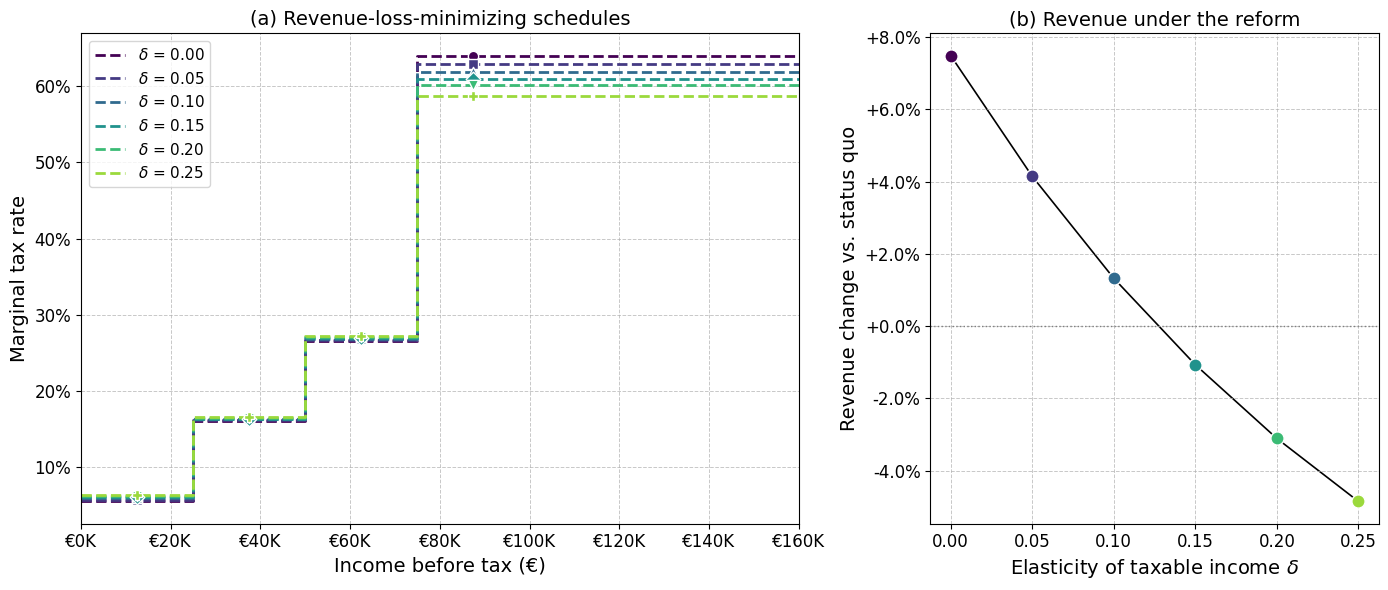

In [5]:
# Figure: revenue-loss-minimizing schedules and revenue change per elasticity
from matplotlib.ticker import FuncFormatter

def pct_vs_sq(revenue):
    # Plot reform revenue on the same income-tax-only basis as REVENUE_SQ.
    return 100.0 * ((revenue - REVENUE_GAP) - REVENUE_SQ) / REVENUE_SQ

# Viridis-sampled colors: perceptually ordered like the elasticity,
# colorblind-safe and monotone in grayscale
colors = plt.cm.viridis(np.linspace(0.0, 0.85, len(DELTAS)))
markers = ['o', 's', '^', 'D', 'v', 'P']

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(14, 6), width_ratios=[1.6, 1])

# --- Left: full schedules ---
for i, delta in enumerate(DELTAS):
    rates = qp_results[delta]['rates']
    x_step, y_step, x_mark, y_mark = [], [], [], []
    for b, rate in enumerate(rates):
        lo = INFLECTION_POINTS[b]
        hi = INFLECTION_POINTS[b + 1]
        x_step.extend([lo, hi])
        y_step.extend([rate, rate])
        x_mark.append((lo + hi) / 2)
        y_mark.append(rate)
    ax.plot(x_step, y_step, color=colors[i], linestyle='--', linewidth=2,
            label=f'$\\delta$ = {delta:.2f}')
    ax.scatter(x_mark, y_mark, color=colors[i], marker=markers[i], s=55,
               zorder=5, edgecolors='white', linewidth=1)

ax.set_xlabel('Income before tax (\u20ac)', fontsize=14)
ax.set_ylabel('Marginal tax rate', fontsize=14)
ax.xaxis.set_major_formatter(FuncFormatter(euro_format))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(0, 160_000)
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
ax.legend(fontsize=11, loc='upper left')
ax.set_title('(a) Revenue-loss-minimizing schedules', fontsize=14)

# --- Right: revenue change vs. status quo ---
rev_pct = [pct_vs_sq(qp_results[d]['revenue']) for d in DELTAS]
ax2.plot(DELTAS, rev_pct, color='black', lw=1.2, zorder=1)
for i, delta in enumerate(DELTAS):
    ax2.scatter(delta, rev_pct[i], color=colors[i], marker='o', s=90,
                zorder=5, edgecolors='white', linewidth=1)

ax2.axhline(0, color='gray', linestyle=':', linewidth=1)
ax2.set_xlabel(r'Elasticity of taxable income $\delta$', fontsize=14)
ax2.set_ylabel('Revenue change vs. status quo', fontsize=14)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:+.1f}%'))
ax2.tick_params(axis='both', labelsize=12)
ax2.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
ax2.set_title('(b) Revenue under the reform', fontsize=14)

plt.tight_layout()
os.makedirs('output', exist_ok=True)
fig.savefig('output/figs/case_3_pareto_schedules.png', dpi=300, bbox_inches='tight')
plt.show()

## Validation: Algorithm 1 (damped fixed-point LP iteration)

The LP-only fallback for solvers without quadratic support. Same minimize-revenue-loss objective per inner solve; incomes updated with damping $\lambda = 0.5$ (the damped map has the same fixed points, but converges where the undamped map oscillates). Reported per elasticity: outer iterations to a \u20ac1 income tolerance, the maximum rate gap vs the direct QP (percentage points), the revenue gap, and how many of the 1,000 taxpayers would cross a bracket cutoff at the fixed point (bracket-stability check).

In [6]:
# Fixed-point validation on the same elasticity grid
DAMPING = 0.5
TOL_INCOME = 1.0   # EUR
MAX_ITER = 40

conv_rows = []
for delta in DELTAS:
    x_new = X_ORIG.copy()
    iters = MAX_ITER
    for it in range(1, MAX_ITER + 1):
        res = solve_reform(delta, x_incomes=x_new, behavioral=False)
        tau_new = res['rates'][BRACKET_IDX]
        x_target = X_ORIG * (1 + delta * (TAU_SQ - tau_new) / (1 - TAU_SQ))
        move = float(np.max(np.abs(x_target - x_new)))
        x_new = (1 - DAMPING) * x_new + DAMPING * x_target
        if move <= TOL_INCOME:
            iters = it
            break

    qp = qp_results[delta]
    new_bracket = np.clip(np.searchsorted(INFLECTION_POINTS, x_new, side='left') - 1, 0, 4)
    conv_rows.append({
        'delta': delta,
        'iterations': iters,
        'rate_gap_pp': float(np.max(np.abs(res['rates'] - qp['rates']))) * 100,
        'revenue_gap': abs(res['revenue'] - qp['revenue']),
        'bracket_crossers': int((new_bracket != BRACKET_IDX).sum()),
    })
    print(conv_rows[-1])

df_conv = pd.DataFrame(conv_rows)
os.makedirs('systems', exist_ok=True)
df_conv.to_excel('systems/case_3_behavioral_convergence.xlsx', index=False)

iter_cells = [f"${int(r['iterations'])}$" for r in conv_rows]
cross_cells = [f"${int(r['bracket_crossers'])}$" for r in conv_rows]
iter_w = max(len(c) for c in iter_cells)
cross_w = max(len(c) for c in cross_cells)
table_rows = []
for r, ic, cc in zip(conv_rows, iter_cells, cross_cells):
    rev = f"{r['revenue_gap']:,.0f}".replace(",", "{,}")
    table_rows.append(
        f"    ${r['delta']:.2f}$ & {ic.ljust(iter_w)} & ${r['rate_gap_pp']:.3f}$ & "
        f"${rev}$ & {cc.ljust(cross_w)} \\\\"
    )

tex = "\n".join([
    "\\begin{table}[!t]",
    "  \\centering",
    "  \\footnotesize",
    "  \\renewcommand{\\arraystretch}{1.25}",
    "  \\begin{tabular}{r r r r r}",
    "    \\toprule",
    "    \\textbf{Elasticity $\\delta$} & \\textbf{Iterations} & \\textbf{Rate gap (pp)} & \\textbf{Revenue gap (\\euro)} & \\textbf{Bracket crossers} \\\\",
    "    \\cmidrule(lr){1-1}\\cmidrule(lr){2-2}\\cmidrule(lr){3-4}\\cmidrule(lr){5-5}",
    *table_rows,
    "    \\bottomrule",
    "  \\end{tabular}",
    "  \\caption{Convergence of the damped fixed-point iteration of Algorithm 1 of the main text ($\\lambda = 0.5$, income tolerance \\euro1) across elasticities of taxable income $\\delta \\in [0, 0.25]$, and validation against the direct nonconvex quadratic solve, on the single-group single-rule instance with 1{,}000 taxpayers. The iteration count is the number of outer iterations (one LP solve each) to reach the income tolerance. The rate gap is the maximum absolute difference (percentage points) between the fixed-point rates and the direct-solve rates; the revenue gap is the corresponding difference in total tax revenue: the two methods bound the revenue-loss-minimizing reform slightly differently (up to $0.22\\%$ of revenue at $\\delta = 0.25$), while the rate schedules still nearly coincide. Bracket crossers counts taxpayers whose responding income leaves their status-quo bracket at the fixed point, quantifying the bracket-stability assumption.}",
    "  \\label{table: behavioral_convergence}",
    "\\end{table}",
    "",
])
os.makedirs("output/tables", exist_ok=True)
with open("output/tables/table_behavioral_convergence.tex", "w", encoding="utf-8") as fh:
    fh.write(tex)

Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!
Found at least one feasible solution!
{'delta': 0.0, 'iterations': 1, 'rate_gap_pp': 0.0, 'revenue_gap': 0.0, 'bracket_crossers': 0}
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19991111.0
New Maximum: 980008889.0
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19547021.472948477
New Maximum: 980452978.5270516
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19341788.04401005
New Maximum: 980658211.95599
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19247049.347270135
New Maximum: 980752950.6527299
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19203323.90595715
New Maximum: 980796676.0940429
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19183135.899972934
New Maximum: 980816864.1000271
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19173809.183664985
New Maximum: 980826190.816335
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -19169496.795143243
New Maximum: 980830503.2048568
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


...

Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16832061.99791213
New Maximum: 983167938.0020878
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16823339.525723014
New Maximum: 983176660.474277
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16819304.627420228
New Maximum: 983180695.3725798
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16817304.209964294
New Maximum: 983182695.7900357
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16816281.6420694
New Maximum: 983183718.3579307
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16815754.16050112
New Maximum: 983184245.8394989
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16815482.233984105
New Maximum: 983184517.7660159
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.
Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16815342.63491206
New Maximum: 983184657.365088
Going to solve!
Found at least one feasible solution!
Directly loading from pd.DataFrame...
Setting 'weight' to 1 as default.
Setting index as the person ID column.
Setting f'person_id_0' as the household ID column.


Mirror household were missing for 1000 households: set to own id
Current tax balance All_households: -16815271.321889076
New Maximum: 983184728.678111
Going to solve!
Found at least one feasible solution!
{'delta': 0.25, 'iterations': 14, 'rate_gap_pp': 0.7809428679383168, 'revenue_gap': 44147.88272532076, 'bracket_crossers': 85}
